# Exercise 1: Linear Algebra (20 points)

One of the challenges in machine learning is moving from the formal linear algebra formulation to a practical implementation with discrete vectors.

Let us look again at the NAND gate implementation with a single perceptron node.
The node has two inputs $x_1$ and $x_2$ and a single output.

The perceptron node implements a transformation between input $\vec{x}$ and output $y$ described by
$$y = f({\bf x}; {\bf w}, b) = {\bf w}^T {\bf x} + b.$$



## Describe the form of the input ${\bf x}$.

Is it a column vector
$\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}$
 or a row vector
$\begin{bmatrix}
x_1
x_2
\end{bmatrix}$
 ? If it were to be implemented as a PyTorch tensor, what should its dimensions be?

 ANS: Its dimension should be a column vector with dimension $\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}$.
 

## Describe the form of the weights ${\bf w}$.

Is it a square array or something else? If it were to be implemented as a PyTorch tensor, what should its dimensions be? Does your answer make sense in the equation above with ${\bf w}^T$?

ANS: It should also be a column vector $\begin{bmatrix}
w_1 \\
w_2
\end{bmatrix}$
 with shape (2X1). Then ${\bf w}^T$ has shape (1X2), (1X2)(2X1) to (1X1).

## Describe the form of the bias $b$.

If it were to be implemented as a PyTorch tensor, what should its dimensions be?

ANS: its a scalar, so $\begin{bmatrix}
1 
\end{bmatrix}$.

## Calculate $y$ with weights and bias

Take $w_1=w_2=-2$ and $b=3$.
Then calculate the perceptron outputs for
- $y =3 f(x_1=0, x_2=0)$
- $y =1 f(x_1=0, x_2=1)$
- $y =1 f(x_1=1, x_2=0)$
- $y =-1 f(x_1=1, x_2=1)$

What final piece is missing in this model, if the goal is produce a truth table with $y$ equal to 0 or 1?
Add the missing piece to your calculation to verify that this model has learned the NAND logic table.

ANS: Its missing an activation function. For y > 0, output is 1; for y <= 0, output is 0.

Now,
- $y =1 $
- $y =1 $
- $y =1 $
- $y =0 $


# Exercise 2: Linear Regression (40 points)

In this exercise we will use a simple perceptron (one node) to calculate the linear regression for the function $f(x) = y$.

In this exercise each data point has a single $x$ and a single $y$.

Fill in the code blocks below to model the regression and predict the output for some test $x$ values.
(Look for the comments marked "TO-DO.")


In [1]:
import torch
from torch.autograd import Variable

torch.manual_seed(42)
x_data_tensor = torch.Tensor([[0.0500],[0.0591],[0.0682],[0.0773],[0.0864],
        [0.0955],[0.1045],[0.1136],[0.1227],[0.1318],
        [0.1409],[0.1500],[0.1591],[0.1682],[0.1773],
        [0.1864],[0.1955],[0.2045],[0.2136],[0.2227],
        [0.2318],[0.2409],[0.2500],[0.2591],[0.2682],
        [0.2773],[0.2864],[0.2955],[0.3045],[0.3136],
        [0.3227],[0.3318],[0.3409],[0.3500],[0.3591],
        [0.3682],[0.3773],[0.3864],[0.3955],[0.4045],
        [0.4136],[0.4227],[0.4318],[0.4409],[0.4500],
        [0.4591],[0.4682],[0.4773],[0.4864],[0.4955],
        [0.5045],[0.5136],[0.5227],[0.5318],[0.5409],
        [0.5500],[0.5591],[0.5682],[0.5773],[0.5864],
        [0.5955],[0.6045],[0.6136],[0.6227],[0.6318],
        [0.6409],[0.6500],[0.6591],[0.6682],[0.6773],
        [0.6864],[0.6955],[0.7045],[0.7136],[0.7227],
        [0.7318],[0.7409],[0.7500],[0.7591],[0.7682],
        [0.7773],[0.7864],[0.7955],[0.8045],[0.8136],
        [0.8227],[0.8318],[0.8409],[0.8500],[0.8591],
        [0.8682],[0.8773],[0.8864],[0.8955],[0.9045],
        [0.9136],[0.9227],[0.9318],[0.9409],[0.9500]])
y_array = [0.2484659, 0.32902399, 0.54115681, 0.3084831,  0.5618252,  0.36455911,
 0.51350721, 0.59238188, 0.50134166, 0.83304367, 0.7044594,  0.86724902,
 0.8560783,  0.97976775, 0.97786013, 0.67360169, 0.94500984, 1.00788982,
 1.12242341, 1.17383408, 1.12468363, 1.13431148, 1.17662245, 1.3324501,
 1.23486871, 1.16412706, 1.36320016, 1.55521281, 1.38178904, 1.49117572,
 1.58999798, 1.7864531,  1.77436729, 1.72934819, 1.66198311, 1.79041017,
 2.20885834, 1.97323221, 2.1730214,  2.01557034, 2.19822747, 2.08018215,
 2.10432378, 2.13234159, 2.0252848,  2.36310875, 2.22574087, 2.21272699,
 2.35988945, 2.30726429, 2.65259961, 2.60177056, 2.82030711, 2.65299176,
 2.63965026, 2.59975554, 2.82430745, 2.81222783, 2.73346561, 2.80687846,
 2.96686021, 3.01237272, 3.12654109, 3.10471933, 3.01646611, 3.22289136,
 3.28936654, 3.05285429, 3.23316291, 3.39834175, 3.42476185, 3.29001894,
 3.43420673, 3.50978013, 3.60845387, 3.75540575, 3.70630173, 3.68288956,
 3.95154621, 3.66087953, 3.9726395,  4.06565774, 4.14370104, 3.86052788,
 4.00409922, 4.08683924, 4.02585529, 4.37126455, 4.19095016, 4.38038983,
 4.32872869, 4.59454492, 4.49190972, 4.4209342,  4.42530996, 4.6364482,
 4.61110624, 4.63337463, 4.73420358, 4.50500814]

# TO-DO: Add code to create the y data tensor here
# It should match the x data tensor in size and shape
y_data_tensor = torch.tensor(y_array).view(-1, 1)

In [2]:
class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # TO-DO: replace M,N with numbers
    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

our_model = LinearRegressionModel()
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(our_model.parameters(), lr = 0.1)
# TO-DO: update the learning rate to a reasonable value

In [3]:
# TO-DO: update to use your data tensors and a reasonable number of epochs
for epoch in range(500):
    # Forward pass: Compute predicted y by passing x to the model
    pred_y = our_model(x_data_tensor)
    loss = criterion(pred_y, y_data_tensor)

    # Zero gradients, perform a backward pass,
    # and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print('epoch {}, loss {}'.format(epoch, loss.item()))

epoch 0, loss 2.8580756187438965
epoch 1, loss 1.9859355688095093
epoch 2, loss 1.4907770156860352
epoch 3, loss 1.2062263488769531
epoch 4, loss 1.039410948753357
epoch 5, loss 0.9384871125221252
epoch 6, loss 0.8745121955871582
epoch 7, loss 0.8313274383544922
epoch 8, loss 0.7999093532562256
epoch 9, loss 0.7752178311347961
epoch 10, loss 0.7544359564781189
epoch 11, loss 0.7359881401062012
epoch 12, loss 0.7189914584159851
epoch 13, loss 0.7029498815536499
epoch 14, loss 0.6875836253166199
epoch 15, loss 0.6727330684661865
epoch 16, loss 0.658306360244751
epoch 17, loss 0.6442491412162781
epoch 18, loss 0.6305283308029175
epoch 19, loss 0.6171225905418396
epoch 20, loss 0.6040172576904297
epoch 21, loss 0.5912013649940491
epoch 22, loss 0.5786662101745605
epoch 23, loss 0.5664042830467224
epoch 24, loss 0.5544091463088989
epoch 25, loss 0.5426743030548096
epoch 26, loss 0.5311940908432007
epoch 27, loss 0.5199627876281738
epoch 28, loss 0.5089749097824097
epoch 29, loss 0.498225063

## Plot the output from your regression model over the same domain as the training data.

Does it make sense? If not, update the training procedure parameters until you are satisfied with the regression model.

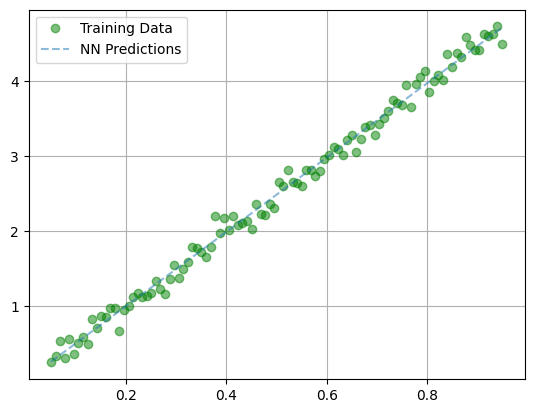

In [4]:
# TO-DO: update INPUT with the correct variables
from matplotlib import pyplot as plt, rcParams
predicted = our_model(x_data_tensor)
plt.plot(x_data_tensor, y_data_tensor, 'go', label='Training Data', alpha=0.5)
plt.plot(x_data_tensor, Variable(predicted), '--', label='NN Predictions', alpha=0.5)
plt.legend(loc='best')
plt.grid()
plt.show()

## Now test on some sample $x$ values

What are the predicted $y$ values for the following?
- $x=-0.2$
- $x=0.8$
- $x=1.5$

In [13]:
# TO-DO: write prediction code here, using the model name

test_x = torch.tensor([[-0.2], [0.8], [1.5]])

our_model.eval()

test_predictions = our_model(test_x)

test_values = [-0.2, 0.8, 1.5]

for x_val, y_pred in zip(test_values, test_predictions):
    print(f"For x = {x_val}, model predicted y = {y_pred.item():.4f}")


For x = -0.2, model predicted y = -0.9778
For x = 0.8, model predicted y = 3.9747
For x = 1.5, model predicted y = 7.4414


# Exercise 3: Perceptron (40 points)

In this exercise we will use a multi-layer perceptron to learn a non-linear function $y=f(x)$.

You are given the $x$ and $y$ data, and the task is to produce a machine learning model that can predict $y$ for any given $x$.

As for Exercise 2, fill in the code blocks below to model the regression and predict the output for some test $x$ values.
(Look for the comments marked "TO-DO.")


In [6]:
import torch
from torch.autograd import Variable
x_data_tensor = torch.tensor([
    [0.0500], [0.0591], [0.0682], [0.0773], [0.0864],
    [0.0955], [0.1045], [0.1136], [0.1227], [0.1318],
    [0.1409], [0.1500], [0.1591], [0.1682], [0.1773],
    [0.1864], [0.1955], [0.2045], [0.2136], [0.2227],
    [0.2318], [0.2409], [0.2500], [0.2591], [0.2682],
    [0.2773], [0.2864], [0.2955], [0.3045], [0.3136],
    [0.3227], [0.3318], [0.3409], [0.3500], [0.3591],
    [0.3682], [0.3773], [0.3864], [0.3955], [0.4045],
    [0.4136], [0.4227], [0.4318], [0.4409], [0.4500],
    [0.4591], [0.4682], [0.4773], [0.4864], [0.4955],
    [0.5045], [0.5136], [0.5227], [0.5318], [0.5409],
    [0.5500], [0.5591], [0.5682], [0.5773], [0.5864],
    [0.5955], [0.6045], [0.6136], [0.6227], [0.6318],
    [0.6409], [0.6500], [0.6591], [0.6682], [0.6773],
    [0.6864], [0.6955], [0.7045], [0.7136], [0.7227],
    [0.7318], [0.7409], [0.7500], [0.7591], [0.7682],
    [0.7773], [0.7864], [0.7955], [0.8045], [0.8136],
    [0.8227], [0.8318], [0.8409], [0.8500], [0.8591],
    [0.8682], [0.8773], [0.8864], [0.8955], [0.9045],
    [0.9136], [0.9227], [0.9318], [0.9409], [0.9500]
])
y_data_tensor = torch.tensor([
    [ 1.7583], [ 1.7594], [ 1.8341], [ 1.6776], [ 1.6192],
    [ 1.6319], [ 1.2830], [ 1.4240], [ 1.2310], [ 1.1797],
    [ 1.1209], [ 1.0473], [ 0.9846], [ 0.8850], [ 0.5541],
    [ 0.6185], [ 0.3247], [ 0.2793], [ 0.2393], [ 0.1914],
    [-0.1365], [-0.3595], [-0.4752], [-0.5761], [-0.7215],
    [-0.6921], [-0.9243], [-0.8667], [-0.8986], [-1.0227],
    [-1.3271], [-1.2883], [-1.4789], [-1.4397], [-1.5957],
    [-1.6669], [-1.6963], [-1.5355], [-1.8969], [-1.8468],
    [-1.9558], [-2.1036], [-2.0511], [-2.0254], [-2.0736],
    [-2.1414], [-2.1034], [-1.8813], [-1.9003], [-1.8852],
    [-1.7806], [-1.8672], [-1.6624], [-1.7309], [-1.6294],
    [-1.4354], [-1.3698], [-1.3055], [-1.2557], [-1.0780],
    [-1.0991], [-0.9720], [-0.6129], [-0.6491], [-0.5295],
    [-0.3640], [-0.2636], [-0.0167], [ 0.0487], [ 0.0429],
    [ 0.1645], [ 0.2342], [ 0.2722], [ 0.6613], [ 0.6190],
    [ 0.8127], [ 1.0884], [ 1.1002], [ 1.0179], [ 1.3273],
    [ 1.2551], [ 1.3914], [ 1.6677], [ 1.5505], [ 1.6793],
    [ 1.6582], [ 1.7866], [ 1.9044], [ 1.8406], [ 1.9540],
    [ 2.0823], [ 2.0165], [ 1.8276], [ 1.9111], [ 2.0306],
    [ 2.2018], [ 1.9585], [ 1.9884], [ 1.8752], [ 1.8503]
])

Check the model being constructed.
What do you think is the best architecture to learn this dataset?
(You can change your mind later.)

In [7]:
# TO-DO: check architecture. Is this right for the problem?
from torch import nn, optim
complex_model = nn.Sequential(
    nn.Linear(1, 10),
    nn.Sigmoid(),
    #nn.Linear(3, 3),
    #nn.Sigmoid(),
    nn.Linear(10, 1)
)

# TO-DO: update the learning rate
criterion = nn.MSELoss()
optimizer = optim.SGD(complex_model.parameters(), lr=0.1)

In [8]:
# TO-DO: update number of epochs
for epoch in range(10000):
    # Forward pass: Compute predicted y by passing x to the model
    pred_y = complex_model(x_data_tensor)
    loss = criterion(pred_y, y_data_tensor)

    # Zero gradients, perform a backward pass,
    # and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print('epoch {}, loss {}'.format(epoch, loss.item()))

epoch 0, loss 2.0480849742889404
epoch 1, loss 1.9825788736343384
epoch 2, loss 1.980155348777771
epoch 3, loss 1.9794377088546753
epoch 4, loss 1.9787684679031372
epoch 5, loss 1.9781029224395752
epoch 6, loss 1.9774388074874878
epoch 7, loss 1.9767770767211914
epoch 8, loss 1.9761172533035278
epoch 9, loss 1.975459337234497
epoch 10, loss 1.9748034477233887
epoch 11, loss 1.9741489887237549
epoch 12, loss 1.973496913909912
epoch 13, loss 1.972846508026123
epoch 14, loss 1.9721978902816772
epoch 15, loss 1.9715514183044434
epoch 16, loss 1.9709064960479736
epoch 17, loss 1.9702633619308472
epoch 18, loss 1.9696221351623535
epoch 19, loss 1.9689828157424927
epoch 20, loss 1.9683451652526855
epoch 21, loss 1.9677091836929321
epoch 22, loss 1.967074990272522
epoch 23, loss 1.9664428234100342
epoch 24, loss 1.965812087059021
epoch 25, loss 1.9651833772659302
epoch 26, loss 1.9645562171936035
epoch 27, loss 1.9639309644699097
epoch 28, loss 1.9633071422576904
epoch 29, loss 1.9626852273941

## Plot the output from your regression model over the same domain as the training data.

Does it make sense? If not, update the training procedure parameters until you are satisfied with the regression model.

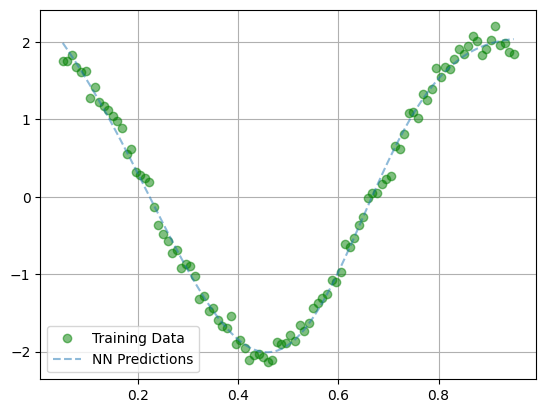

In [9]:
# TO-DO: update INPUT with the correct variables
from matplotlib import pyplot as plt, rcParams
predicted = complex_model(x_data_tensor)
plt.plot(x_data_tensor, y_data_tensor, 'go', label='Training Data', alpha=0.5)
plt.plot(x_data_tensor, Variable(predicted), '--', label='NN Predictions', alpha=0.5)
plt.legend(loc='best')
plt.grid()
plt.show()

## Now test on some sample $x$ values

What are the predicted $y$ values for the following?
- $x=-0.2$
- $x=0.4$
- $x=0.8$

In [10]:
# TO-DO: put your prediction code (aka inference code) here

In [11]:
test_x_complex = torch.tensor([[-0.2], [0.4], [0.8]])

complex_model.eval()
predictions_complex = complex_model(test_x_complex)

for x_val, y_pred in zip([-0.2, 0.4, 0.8], predictions_complex):
    print(f"For x = {x_val}, model predicted y = {y_pred.item():.4f}")



For x = -0.2, model predicted y = 3.5601
For x = 0.4, model predicted y = -1.8442
For x = 0.8, model predicted y = 1.5275
